# Customer Segmentation Analysis

## Oasis Infobyte - Data Analytics Internship
### Level 1 - Task 2

### Objective

The objective of this project is to analyze customer purchasing behavior and segment customers into meaningful groups using RFM (Recency, Frequency, Monetary) analysis and K-Means clustering.

The analysis aims to identify different types of customers based on their purchasing patterns and provide actionable marketing recommendations for each customer segment.

In [2]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Ignore unnecessary warnings
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_excel('C:\Desktop\OIBSIP\DataAnalytics_L1_CustomerSegmentation\Dataset\Online Retail.xlsx')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


### Dataset Shape

Checking the number of rows and columns in the dataset.

In [5]:
df.shape

(541909, 8)

In [6]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

### Dataset Information

The dataset structure, column data types, and non-null values are inspected to understand the quality and format of the data.

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


### Missing Values

Missing values are checked before performing customer segmentation because incomplete customer information may affect the RFM analysis.

In [10]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

### Duplicate Records

Duplicate transactions are checked to prevent repeated records from affecting customer purchase frequency and monetary calculations.

In [12]:
df.duplicated().sum()

5268

### Descriptive Statistics

Summary statistics are generated to understand the distribution and range of numerical variables in the dataset.

In [14]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


## 2. Data Cleaning

Before performing customer segmentation, the dataset is cleaned to ensure that the RFM metrics accurately represent customer purchasing behavior.

The cleaning process includes:
- Handling missing Customer IDs
- Removing duplicate records
- Identifying cancelled transactions
- Removing invalid quantities and prices
- Creating a total transaction value

In [16]:
# Percentage of missing values
(df.isnull().sum() / len(df) * 100).round(2)

InvoiceNo       0.00
StockCode       0.00
Description     0.27
Quantity        0.00
InvoiceDate     0.00
UnitPrice       0.00
CustomerID     24.93
Country         0.00
dtype: float64

### Handling Missing Customer IDs

CustomerID is essential for customer-level segmentation. Transactions without a CustomerID cannot be assigned to a specific customer and therefore cannot be used reliably for RFM analysis.

Hence, records with missing CustomerID values are removed.

In [18]:
# Remove records with missing CustomerID
df_clean = df.dropna(subset=['CustomerID']).copy()

df_clean.shape

(406829, 8)

In [19]:
df_clean.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [20]:
df_clean.duplicated().sum()

5225

### Removing Duplicate Records

Duplicate transaction records can artificially increase purchase frequency and customer spending. Therefore, exact duplicate rows are identified and removed before calculating RFM metrics.

In [22]:
# Check number of rows before removing duplicates
print("Rows before removing duplicates:", len(df_clean))

# Remove exact duplicate records
df_clean = df_clean.drop_duplicates().copy()

# Check number of rows after removing duplicates
print("Rows after removing duplicates:", len(df_clean))

# Verify duplicates
print("Remaining duplicates:", df_clean.duplicated().sum())

Rows before removing duplicates: 406829
Rows after removing duplicates: 401604
Remaining duplicates: 0


### Identifying Cancelled Transactions

Cancelled or returned transactions should be examined separately because they do not represent completed customer purchases and may distort RFM-based customer segmentation.

In [24]:
# Identify cancelled transactions
cancelled = df_clean[
    df_clean['InvoiceNo'].astype(str).str.startswith('C')
]

print("Cancelled transaction rows:", len(cancelled))

cancelled.head()

Cancelled transaction rows: 8872


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom


In [25]:
print("Negative/Zero Quantity:",
      (df_clean['Quantity'] <= 0).sum())

print("Negative/Zero UnitPrice:",
      (df_clean['UnitPrice'] <= 0).sum())

Negative/Zero Quantity: 8872
Negative/Zero UnitPrice: 40


### Removing Cancelled and Invalid Transactions

Cancelled transactions have invoice numbers beginning with "C" and contain negative quantities. Since these transactions represent returns or cancellations rather than completed purchases, they are excluded from the customer segmentation analysis.

Transactions with zero or negative UnitPrice are also removed because they do not represent valid revenue-generating purchases.

In [27]:
# Keep only valid completed transactions
df_clean = df_clean[
    (df_clean['Quantity'] > 0) &
    (df_clean['UnitPrice'] > 0)
].copy()

print("Cleaned dataset shape:", df_clean.shape)

Cleaned dataset shape: (392692, 8)


In [28]:
print("Missing CustomerID:", df_clean['CustomerID'].isnull().sum())
print("Duplicate rows:", df_clean.duplicated().sum())
print("Quantity <= 0:", (df_clean['Quantity'] <= 0).sum())
print("UnitPrice <= 0:", (df_clean['UnitPrice'] <= 0).sum())
print("Cancelled invoices:",
      df_clean['InvoiceNo'].astype(str).str.startswith('C').sum())

Missing CustomerID: 0
Duplicate rows: 0
Quantity <= 0: 0
UnitPrice <= 0: 0
Cancelled invoices: 0


### Data Type Correction

CustomerID is converted from float to integer because it is an identifier rather than a continuous numerical variable.

In [30]:
df_clean['CustomerID'] = df_clean['CustomerID'].astype(int)

df_clean[['CustomerID']].head()

,CustomerID
0,17850
1,17850
2,17850
3,17850
4,17850


### Creating Total Transaction Value

A new feature called `TotalPrice` is created by multiplying the quantity purchased by the unit price. This represents the monetary value of each transaction and will later be used to calculate customer-level monetary value.

In [32]:
# Calculate total transaction value
df_clean['TotalPrice'] = (
    df_clean['Quantity'] * df_clean['UnitPrice']
)

df_clean[['Quantity', 'UnitPrice', 'TotalPrice']].head()

,Quantity,UnitPrice,TotalPrice
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


In [33]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 392692 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    392692 non-null  object        
 1   StockCode    392692 non-null  object        
 2   Description  392692 non-null  object        
 3   Quantity     392692 non-null  int64         
 4   InvoiceDate  392692 non-null  datetime64[ns]
 5   UnitPrice    392692 non-null  float64       
 6   CustomerID   392692 non-null  int32         
 7   Country      392692 non-null  object        
 8   TotalPrice   392692 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int32(1), int64(1), object(4)
memory usage: 28.5+ MB


In [34]:
df_clean.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


In [35]:
print("Cleaned dataset shape:", df_clean.shape)

Cleaned dataset shape: (392692, 9)


## 3. RFM Analysis

RFM analysis is used to understand customer purchasing behavior using three key metrics:

- **Recency (R):** Number of days since the customer's most recent purchase.
- **Frequency (F):** Number of unique purchases made by the customer.
- **Monetary (M):** Total amount spent by the customer.

These behavioral features will be used for customer segmentation using K-Means clustering.

In [37]:
df_clean['InvoiceDate'].max()

Timestamp('2011-12-09 12:50:00')

### Reference Date

The reference date is set to one day after the latest transaction date in the dataset. This date is used to calculate the number of days since each customer's most recent purchase.

In [39]:
# Set reference date as one day after the latest transaction
reference_date = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)

print("Reference Date:", reference_date)

Reference Date: 2011-12-10 12:50:00


### Calculating RFM Metrics

Customer-level RFM metrics are calculated by grouping transactions by CustomerID:

- Recency: Days since the customer's latest purchase
- Frequency: Number of unique invoices
- Monetary: Total amount spent

In [41]:
rfm = df_clean.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (reference_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalPrice': 'sum'
}).reset_index()

# Rename columns
rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']

rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346,326,1,77183.60
1,12347,2,7,4310.00
2,12348,75,4,1797.24
3,12349,19,1,1757.55
4,12350,310,1,334.40


In [42]:
print("Number of customers:", rfm.shape[0])
print("Number of RFM features:", rfm.shape[1] - 1)

rfm.shape

Number of customers: 4338
Number of RFM features: 3


(4338, 4)

In [43]:
rfm[['Recency', 'Frequency', 'Monetary']].describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2048.688081
std,100.014169,7.697998,8985.230220
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,306.482500
50%,51.000000,2.000000,668.570000
75%,142.000000,5.000000,1660.597500
max,374.000000,209.000000,280206.020000


## 4. RFM Distribution and Outlier Analysis

Before applying K-Means clustering, the distributions of Recency, Frequency, and Monetary are examined.

K-Means is sensitive to extreme values because it groups observations based on distance. Therefore, identifying skewness and potential outliers is important before scaling and clustering.

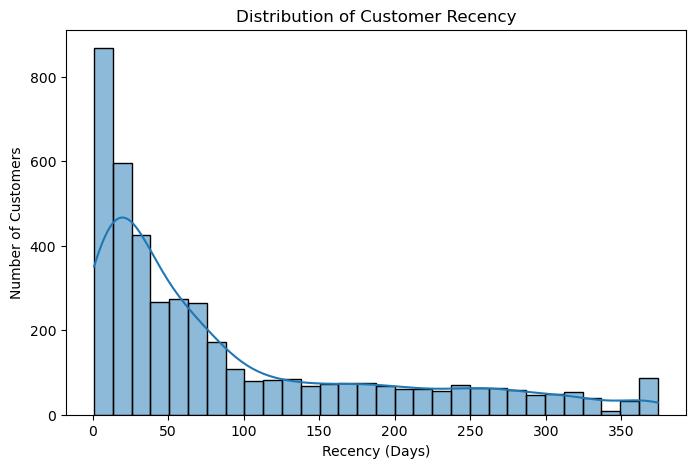

In [45]:
plt.figure(figsize=(8,5))

sns.histplot(rfm['Recency'], bins=30, kde=True)

plt.title('Distribution of Customer Recency')
plt.xlabel('Recency (Days)')
plt.ylabel('Number of Customers')

plt.show()

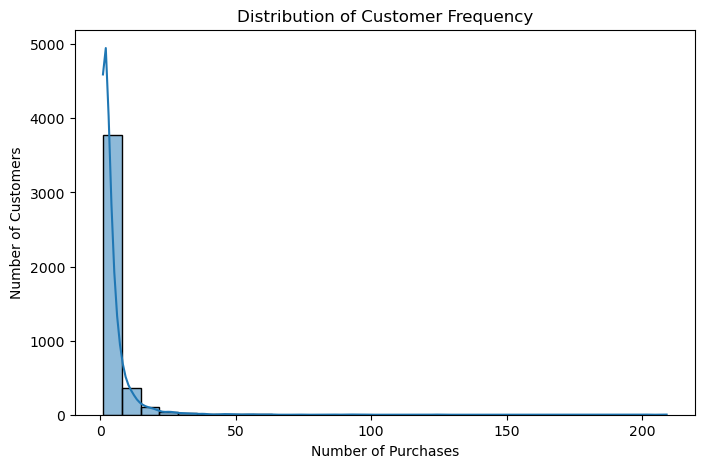

In [46]:
plt.figure(figsize=(8,5))

sns.histplot(rfm['Frequency'], bins=30, kde=True)

plt.title('Distribution of Customer Frequency')
plt.xlabel('Number of Purchases')
plt.ylabel('Number of Customers')

plt.show()

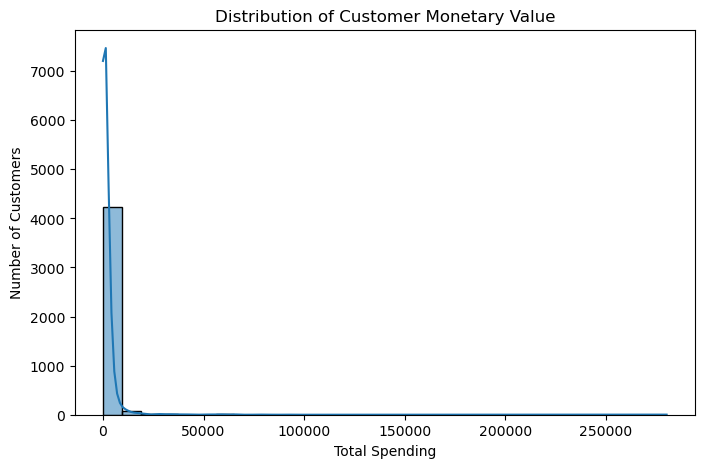

In [47]:
plt.figure(figsize=(8,5))

sns.histplot(rfm['Monetary'], bins=30, kde=True)

plt.title('Distribution of Customer Monetary Value')
plt.xlabel('Total Spending')
plt.ylabel('Number of Customers')

plt.show()

In [48]:
rfm[['Recency', 'Frequency', 'Monetary']].skew()

Recency       1.246048
Frequency    12.067031
Monetary     19.339368
dtype: float64

### Handling Skewness

The RFM variables, particularly Frequency and Monetary, are highly right-skewed. Since K-Means clustering is distance-based and sensitive to extreme distributions, a logarithmic transformation is applied to reduce skewness.

The original RFM values are preserved for business interpretation, while transformed values are used for clustering.

In [50]:
# Create a copy for clustering
rfm_transformed = rfm[['Recency', 'Frequency', 'Monetary']].copy()

# Apply log transformation
rfm_transformed = np.log1p(rfm_transformed)

rfm_transformed.head()

,Recency,Frequency,Monetary
0,5.789960,0.693147,11.253955
1,1.098612,2.079442,8.368925
2,4.330733,1.609438,7.494564
3,2.995732,0.693147,7.472245
4,5.739793,0.693147,5.815324


In [51]:
rfm_transformed.skew()

Recency     -0.379169
Frequency    1.208652
Monetary     0.396599
dtype: float64

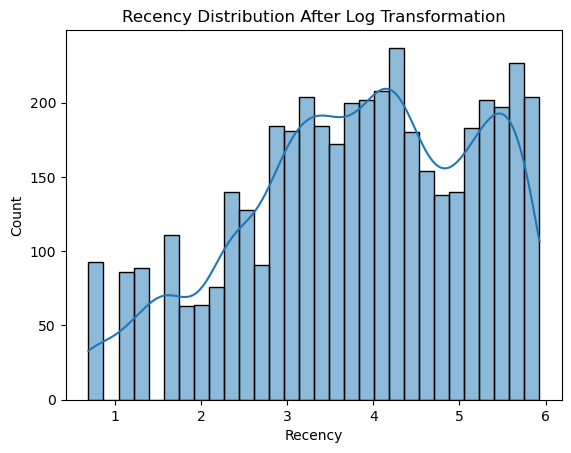

In [52]:
sns.histplot(rfm_transformed['Recency'], bins=30, kde=True)
plt.title('Recency Distribution After Log Transformation')
plt.show()

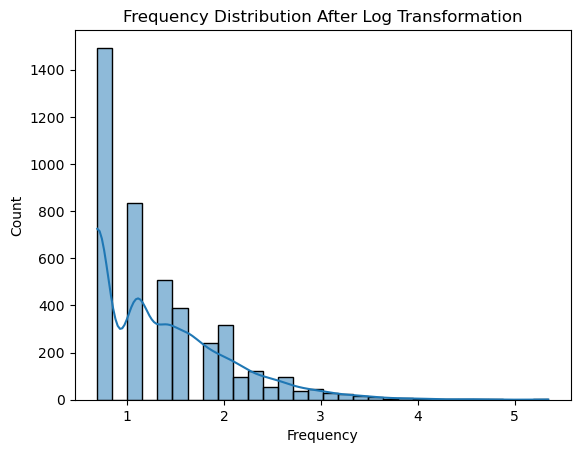

In [53]:
sns.histplot(rfm_transformed['Frequency'], bins=30, kde=True)
plt.title('Frequency Distribution After Log Transformation')
plt.show()

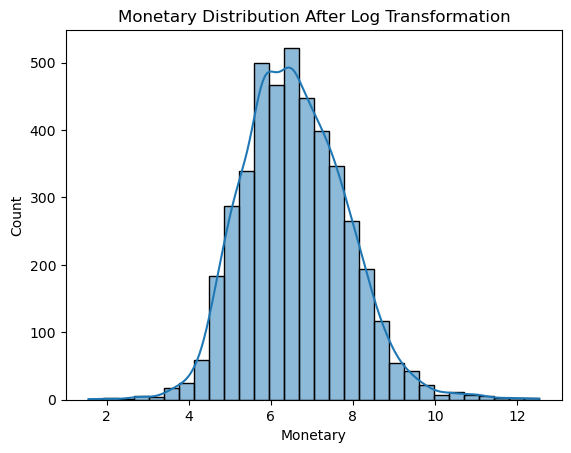

In [54]:
sns.histplot(rfm_transformed['Monetary'], bins=30, kde=True)
plt.title('Monetary Distribution After Log Transformation')
plt.show()

## 5. Feature Scaling

After reducing skewness using logarithmic transformation, the RFM features are standardized using StandardScaler.

Standardization transforms the features to have approximately a mean of 0 and a standard deviation of 1. This ensures that Recency, Frequency, and Monetary contribute fairly to the distance calculations used by K-Means clustering.

In [56]:
# Initialize StandardScaler
scaler = StandardScaler()

# Standardize transformed RFM features
rfm_scaled = scaler.fit_transform(rfm_transformed)

# Convert the scaled array into a DataFrame
rfm_scaled = pd.DataFrame(
    rfm_scaled,
    columns=['Recency', 'Frequency', 'Monetary'],
    index=rfm.index
)

rfm_scaled.head()

,Recency,Frequency,Monetary
0,1.461993,-0.955214,3.707716
1,-2.038734,1.074425,1.414903
2,0.373104,0.386304,0.720024
3,-0.623086,-0.955214,0.702287
4,1.424558,-0.955214,-0.614514


In [57]:
rfm_scaled.describe().round(2)

,Recency,Frequency,Monetary
count,4338.00,4338.00,4338.00
mean,-0.00,-0.00,-0.00
std,1.00,1.00,1.00
min,-2.34,-0.96,-4.00
25%,-0.66,-0.96,-0.68
50%,0.09,-0.36,-0.07
75%,0.84,0.65,0.66
max,1.56,5.86,4.73


In [58]:
import os
os.environ["LOKY_MAX_CPU_COUNT"] = "4"

## 6. Determining the Optimal Number of Clusters

The Elbow Method is used to determine an appropriate number of clusters for K-Means. It compares the Within-Cluster Sum of Squares (WCSS/Inertia) for different values of K.

The point where the reduction in inertia begins to slow noticeably is considered a suitable number of clusters.

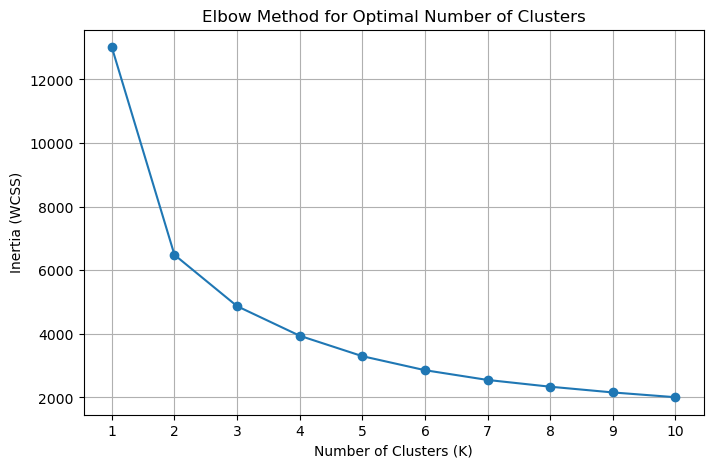

In [60]:
# Calculate inertia for different values of K
inertia = []

k_values = range(1, 11)

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

# Plot Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(k_values, inertia, marker='o')

plt.title('Elbow Method for Optimal Number of Clusters')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (WCSS)')
plt.xticks(k_values)
plt.grid(True)

plt.show()

### Elbow Method Observation

The inertia decreases sharply from K=1 to K=2 and continues to decrease noticeably up to K=3. After K=3, the rate of improvement becomes more gradual.

Therefore, K=3 is selected as an appropriate number of clusters for customer segmentation.

## K-Means Customer Segmentation

Based on the Elbow Method, three clusters are selected. K-Means clustering is applied to the standardized RFM features to group customers with similar purchasing behavior.

In [63]:
# Apply K-Means with 3 clusters
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

# Assign cluster labels
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

rfm.head()

,CustomerID,Recency,Frequency,Monetary,Cluster
0,12346,326,1,77183.60,2
1,12347,2,7,4310.00,0
2,12348,75,4,1797.24,2
3,12349,19,1,1757.55,2
4,12350,310,1,334.40,1


In [64]:
rfm['Cluster'].value_counts().sort_index()

Cluster
0     769
1    1872
2    1697
Name: count, dtype: int64

In [65]:
cluster_profile = rfm.groupby('Cluster').agg({
    'CustomerID': 'count',
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean'
}).round(2)

cluster_profile.rename(
    columns={'CustomerID': 'Number_of_Customers'},
    inplace=True
)

cluster_profile

,Number_of_Customers,Recency,Frequency,Monetary
Cluster,,,,
0,769,17.06,13.35,7898.46
1,1872,167.36,1.35,361.00
2,1697,44.20,3.38,1259.58


### Cluster Profile Interpretation

Based on the average RFM characteristics:

- **Cluster 0 – High-Value Customers:** These customers have the lowest average recency, highest purchase frequency, and highest monetary value. They represent the most valuable and loyal customer segment.

- **Cluster 1 – At-Risk Customers:** These customers have the highest recency and the lowest frequency and monetary value. They purchase infrequently and have not purchased recently.

- **Cluster 2 – Regular Customers:** These customers have moderate recency, frequency, and monetary values. They represent active customers with the potential to become high-value customers.

In [67]:
segment_map = {
    0: 'High-Value Customers',
    1: 'At-Risk Customers',
    2: 'Regular Customers'
}

rfm['Segment'] = rfm['Cluster'].map(segment_map)

rfm.head()

,CustomerID,Recency,Frequency,Monetary,Cluster,Segment
0,12346,326,1,77183.60,2,Regular Customers
1,12347,2,7,4310.00,0,High-Value Customers
2,12348,75,4,1797.24,2,Regular Customers
3,12349,19,1,1757.55,2,Regular Customers
4,12350,310,1,334.40,1,At-Risk Customers


## Customer Segment Visualization

### Number of Customers by Segment

The following chart shows the distribution of customers across the identified customer segments.

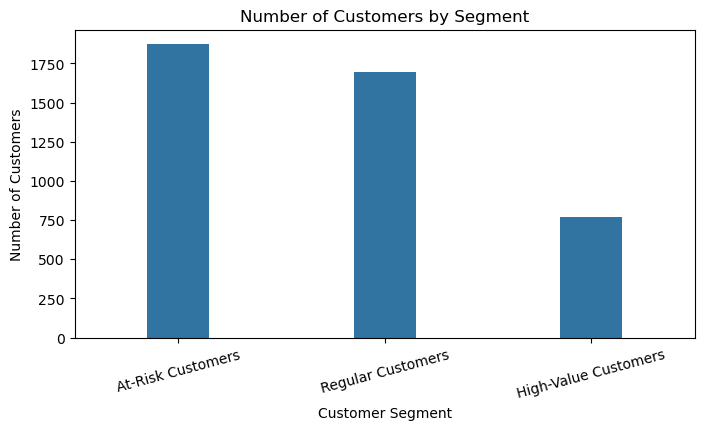

In [143]:
segment_counts = rfm['Segment'].value_counts()

plt.figure(figsize=(8, 4))

sns.barplot(
    x=segment_counts.index,
    y=segment_counts.values, width=0.3
)

plt.title('Number of Customers by Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=15)

plt.show()

### Observation

The At-Risk segment contains the largest number of customers (1,872), followed by Regular Customers (1,697). High-Value Customers represent the smallest segment with 769 customers.

This indicates a significant opportunity to re-engage at-risk customers while encouraging regular customers to increase their purchase frequency and move toward the high-value segment.

### Recency vs Frequency by Customer Segment

This visualization compares how recently customers purchased with how frequently they purchase, helping identify differences in purchasing activity across customer segments.

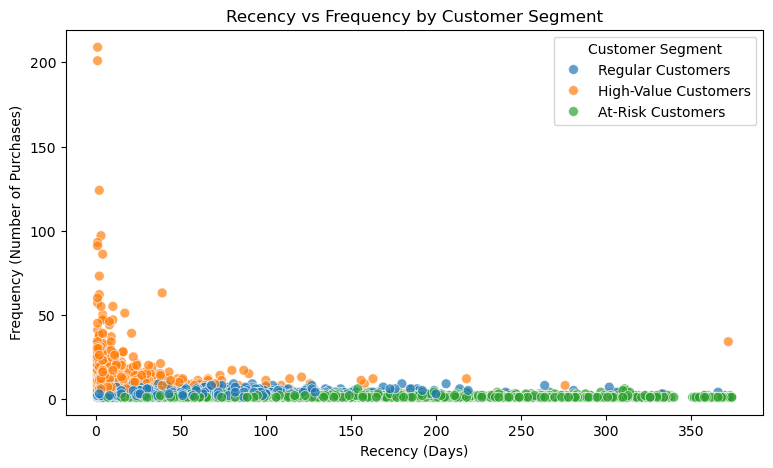

In [147]:
plt.figure(figsize=(9, 5))

sns.scatterplot(
    data=rfm,
    x='Recency',
    y='Frequency',
    hue='Segment',
    s=50,
    alpha=0.7
)

plt.title('Recency vs Frequency by Customer Segment')
plt.xlabel('Recency (Days)')
plt.ylabel('Frequency (Number of Purchases)')
plt.legend(title='Customer Segment')

plt.show()

### Observation

High-Value Customers generally have low recency and high purchase frequency, indicating that they purchase recently and frequently.

At-Risk Customers tend to have high recency and low frequency, showing that they have not purchased recently and make fewer purchases.

Regular Customers are primarily positioned between these two groups, representing moderately active customers.

### Frequency vs Monetary Value by Customer Segment

This visualization compares customer purchase frequency with total spending to understand how purchasing activity relates to customer monetary value.

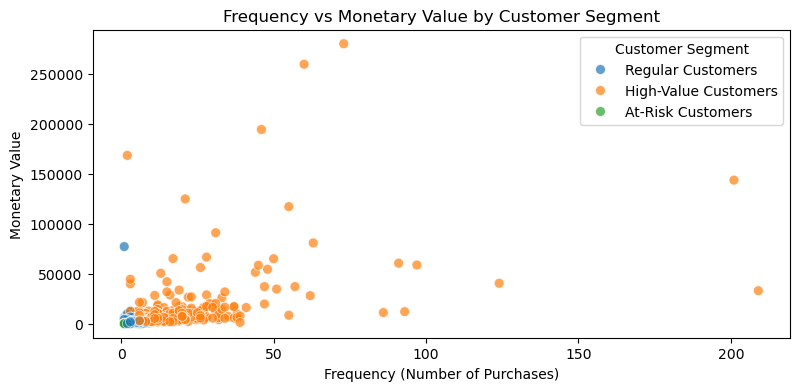

In [151]:
plt.figure(figsize=(9, 4))

sns.scatterplot(
    data=rfm,
    x='Frequency',
    y='Monetary',
    hue='Segment',
    s=50,
    alpha=0.7
)

plt.title('Frequency vs Monetary Value by Customer Segment')
plt.xlabel('Frequency (Number of Purchases)')
plt.ylabel('Monetary Value')
plt.legend(title='Customer Segment')

plt.show()

### Observation

High-Value Customers generally show higher purchase frequency and monetary value, confirming that frequent buyers contribute significantly more revenue.

At-Risk Customers are concentrated at low frequency and low monetary values.

Regular Customers show moderate purchase frequency and spending, indicating an opportunity to increase their value through targeted promotions and loyalty strategies.

### Average RFM Characteristics by Customer Segment

In [78]:
segment_profile = rfm.groupby('Segment')[
    ['Recency', 'Frequency', 'Monetary']
].mean().round(2)

segment_profile

,Recency,Frequency,Monetary
Segment,,,
At-Risk Customers,167.36,1.35,361.00
High-Value Customers,17.06,13.35,7898.46
Regular Customers,44.20,3.38,1259.58


## Marketing Recommendations

Based on the RFM characteristics of the three customer segments, the following marketing strategies are recommended:

### High-Value Customers
- Provide loyalty rewards, VIP benefits, and exclusive offers to retain these valuable customers.
- Offer early access to new products and personalized recommendations.
- Use cross-selling and upselling strategies to further increase customer lifetime value.

### Regular Customers
- Encourage repeat purchases through personalized discounts and loyalty programs.
- Recommend products based on previous purchasing behavior.
- Use targeted promotions to increase purchase frequency and move these customers toward the high-value segment.

### At-Risk Customers
- Launch re-engagement campaigns using special discounts or limited-time offers.
- Send personalized reminders and product recommendations to encourage customers to return.
- Analyze reasons for inactivity and use win-back campaigns to reduce customer loss.

## Conclusion

The customer segmentation analysis successfully grouped 4,338 customers into three meaningful segments using RFM analysis and K-Means clustering.

- **High-Value Customers** are the most active and profitable customers, characterized by recent purchases, high purchase frequency, and high monetary value.
- **Regular Customers** demonstrate moderate purchasing activity and represent an important opportunity for conversion into high-value customers.
- **At-Risk Customers** purchase less frequently, spend less, and have not purchased recently, indicating a need for targeted re-engagement strategies.

The analysis demonstrates how customer segmentation can help businesses better understand purchasing behavior and develop targeted marketing strategies for customer retention, engagement, and revenue growth.

In [81]:
rfm.to_csv(
    r'C:/Desktop/OIBSIP/DataAnalytics_L1_CustomerSegmentation/Outputs/customer_segmentation_results.csv',
    index=False
)

print("Customer segmentation results exported successfully.")

Customer segmentation results exported successfully.


In [82]:
df_clean.to_csv(
    r'C:/Desktop/OIBSIP/DataAnalytics_L1_CustomerSegmentation/Outputs/cleaned_online_retail.csv',
    index=False
)

print("Cleaned retail dataset exported successfully.")

Cleaned retail dataset exported successfully.
